<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [6]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [8]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [9]:
b_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [10]:
b_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


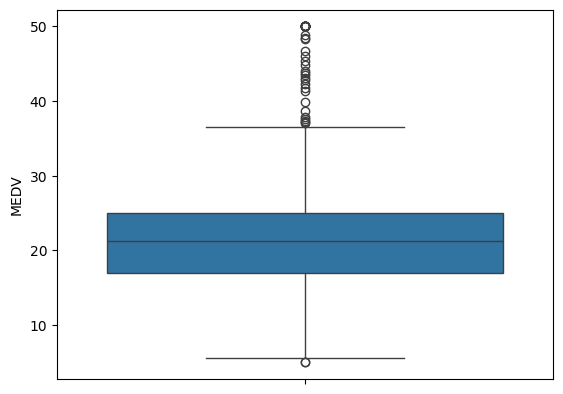

In [12]:
ax = sns.boxplot(y='MEDV', data=b_df)
plt.show()

#### 1. Is there a significant difference in the median value of houses bounded by the Charles river or not?

In [15]:
medv_chas = b_df.groupby('CHAS')[['MEDV']].mean().reset_index()
medv_chas

,CHAS,MEDV
0,0.0,22.093843
1,1.0,28.440000


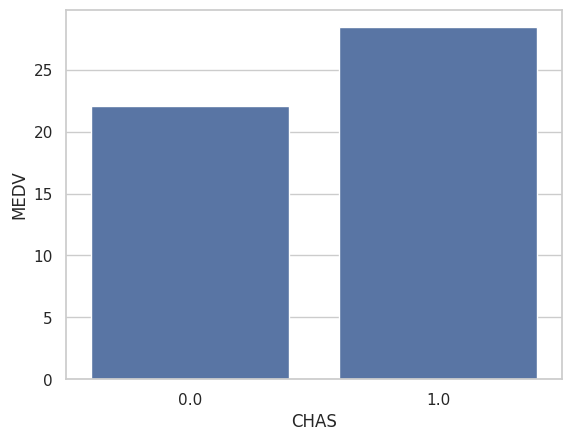

In [16]:
sns.set(style="whitegrid")
ax = sns.barplot(x="CHAS", y="MEDV", data=medv_chas)
plt.show()

In [22]:
print('H0: there is no difference in the median value of houses bounded by the Charles river or not')
print('H1: there is a difference in the median value of houses bounded by the Charles river or not')
print('')
ss1 = scipy.stats.ttest_ind(b_df[b_df['CHAS'] == 0]['MEDV'],
                   b_df[b_df['CHAS'] == 1]['MEDV'], equal_var = True)
print(f"t-stat {ss1[0]}, p-value {ss1[1]}")
print('')
if ss1[1] <0.05:
    print("""Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is a difference in the median value of houses bounded by the Charles river or not""")
else:
    print('Since the p-value is not less than alpha value 0.05, we do not have enought proof to reject null hypothesis')

H0: there is no difference in the median value of houses bounded by the Charles river or not
H1: there is a difference in the median value of houses bounded by the Charles river or not

t-stat -3.996437466090509, p-value 7.390623170519905e-05

Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is a difference in the median value of houses bounded by the Charles river or not


#### 2. Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

In [23]:
import numpy as np
b_df['age group'] = np.where(b_df['AGE']<=35,1,2)
b_df['age group'] = np.where(b_df['AGE']>=70,3,b_df['age group'])
b_df.groupby('age group')[['MEDV']].mean().reset_index()


,age group,MEDV
0,1,27.775824
1,2,24.947656
2,3,19.793380


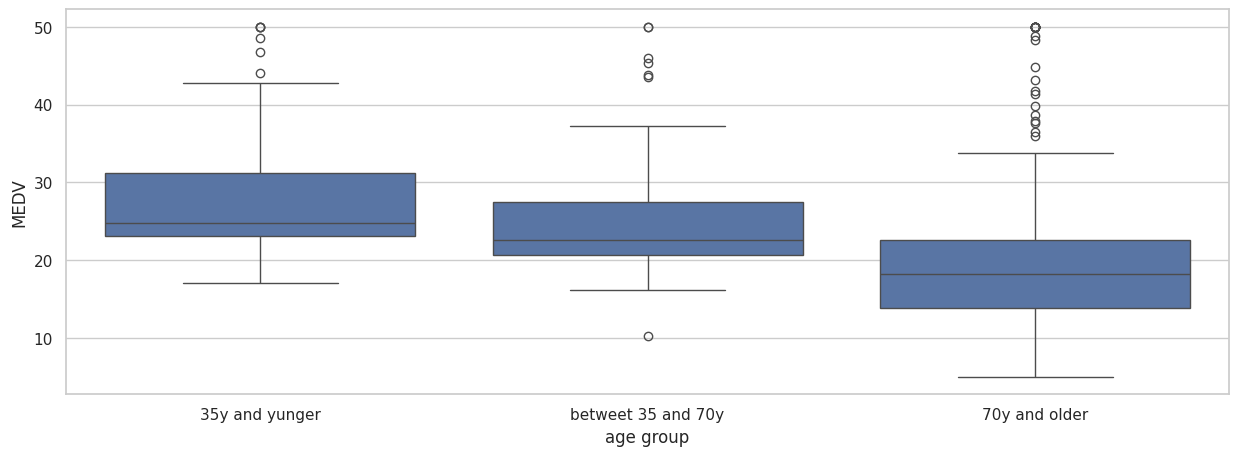

In [26]:
fig, (ax) = plt.subplots(1,1,figsize=(15,5))
ax = sns.boxplot(x='age group', y='MEDV', data=b_df)
ax.set_xticks([0,1,2])
ax.set_xticklabels(['35y and yunger','betweet 35 and 70y','70y and older'])
plt.show()

In [27]:
age_group1 = b_df[b_df['age group'] == 1]['MEDV']
age_group2 = b_df[b_df['age group'] == 2]['MEDV']
age_group3 = b_df[b_df['age group'] == 3]['MEDV']
f_statistic, p_value = scipy.stats.f_oneway(age_group1 , age_group2 , age_group3 )
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic,p_value))

F_Statistic: 36.40764999196599, P-Value: 1.7105011022702984e-15


In [28]:
print('H0: the three population means are equal')
print('H1: At least one of the means differ')
print('')
print('')
if p_value <0.05:
    print("""Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there a difference in median values of houses of each proportion of owner-occupied units built before 1940""")
else:
    print('Since the p-value is not less than alpha value 0.05, we do not have enought proof to reject null hypothesis')

H0: the three population means are equal
H1: At least one of the means differ


Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there a difference in median values of houses of each proportion of owner-occupied units built before 1940


#### 3. Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

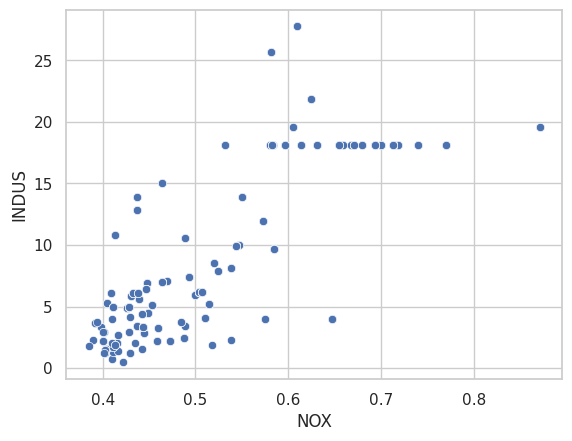

In [29]:
ax= sns.scatterplot(x='NOX', y='INDUS', data=b_df)
plt.show()

In [31]:
print('H0: Nitric oxide concentrations is not corelated with the proportion of non-retail business acres per town')
print('H1: Nitric oxide concentrations is corelated with the proportion of non-retail business acres per town')
print('')
ss3 = scipy.stats.pearsonr(b_df['NOX'], b_df['INDUS'])
print(f"t-stat {ss3[0]}, p-value {ss3[1]}")
print('')
if ss3[1] <0.05:
    print("""Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town""")
else:
    print('Since the p-value is not less than alpha value 0.05, we do not have enought proof to reject null hypothesis')

H0: Nitric oxide concentrations is not corelated with the proportion of non-retail business acres per town
H1: Nitric oxide concentrations is corelated with the proportion of non-retail business acres per town

t-stat 0.7636514469209192, p-value 7.913361061210442e-98

Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town


#### 4. What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

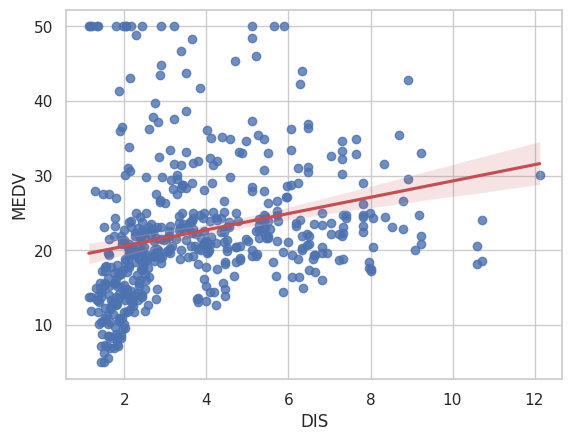

In [35]:
sns.regplot(x='DIS', y='MEDV', line_kws={"color":'r'},data=boston_df, scatter=True)
plt.show()

In [37]:
X=b_df['DIS']
y= b_df['MEDV']
X=sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Wed, 08 Jan 2025   Prob (F-statistic):           1.21e-08
Time:                        13:33:27   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
print('H0: coef = 0 (distance to the five Boston employment centres has no effect on the median value of owner-occupied homes)')
print('H1: coef differ then 0 (distance to the five Boston employment centres has effect on the median value of owner-occupied homes)')
print('')
print('')
print("""Since the p-value of model and coef DIS  are less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
so distance to the five Boston employment centres has effect on the median value of owner-occupied homes""")


H0: coef = 0 (distance to the five Boston employment centres has no effect on the median value of owner-occupied homes)
H1: coef differ then 0 (distance to the five Boston employment centres has effect on the median value of owner-occupied homes)


Since the p-value of model and coef DIS  are less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
so distance to the five Boston employment centres has effect on the median value of owner-occupied homes
